In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Neural Network:

#### Structure of a Neural Network includes:
- input array
- hidden layers (that includes neurons that do intermediate calculations)
- output (that takes the hidden layers and it's weights) to calculate the final output

It looks like:

$input \rightarrow hidden \: layers \rightarrow output$

#### **Hidden Layer:**
- intermediate layer helps the model learn any nonlinear relationships in the data for it to best be captured in the output
- can go through multiple layers before the output calculates its predicted final value.
- Multiple nodes in the layer (can vary in amount), that each have a final value based off all the x values and weights assigned to each input value
- Then, these nodes get reused for the next layer, and so on until the output uses the final hidden layer.

#### **How do the calculations work?**
Let's say we have input values $x_1, x_2, x_3$. The first step is to get calculate the hidden layer
- Each node contains a bias value $b$ and assigns weight values to each of the input nodes.
- If we have 3 nodes in the hidden layer, then we have weights $w_{11}, w_{21}, w_{31}$ for the first node, weights $w_{12}, w_{22}, w_{32}$ for the second node, and weights $w_{13}, w_{23}, w_{33}$ for the 3rd node. Weight $w_{11}$ is the weight that corresponds to $x_1$ that is assigned by node 1.
- Weights can be trained with backpropogation using methods like gradient descent (later in this notebook)
- Each node has an activation function that it uses to help learn non-linear relations. The most common are Sigmoid, TanH, and ReLU.

**Sigmoid Function** - used by logistic regression and with input $x$, produces a value $y \in [0, 1]$. Equation is:
$$F(x) = \frac{1}{1+e^{-x}}$$

**TanH Function** - Short for hyperbolic tangent, with input $x$, it produces a value $y \in [-1, 1]$. Equation is:
$$F(x) = tanh(x)$$

**ReLU function** - The rectified linear unit activation function returns $0$ if input $x <0$ and the input value if not. Equation is:
$$F(x) = max(0, x)$$

With that, each node takes the weights, biases, and x values and, with the activation function, gets an output value for that node. The input for the activation function follows a linear model: $y = w_1x_1 + w_2x_2 + w_3x_3 + b$. So, if we use the Sigmoid function, the value of the node would be:
$$y' = Sigmoid(w_1x_1 + w_2x_2 + w_3x_3 + b)$$

Each layer in the network repeats this same process with the previous layer as the input. Finally, the output node performs a final calculation with the last hidden layer as inputs. The output is just one node, so there is only one set of weights for this node.

Note: ReLU functions are less susceptible to the vanishing gradient problem, or the The tendency for the gradients of early hidden layers of some deep neural networks to become surprisingly flat (low). (Google)

In [2]:
# Setting up torch
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
# create a 100x3 tensor
tensor = torch.rand((100, 3), dtype=torch.float)
tensor

tensor([[0.7975, 0.1024, 0.2821],
        [0.6324, 0.8907, 0.9742],
        [0.6839, 0.7649, 0.7179],
        [0.3560, 0.1564, 0.0413],
        [0.4783, 0.5307, 0.5060],
        [0.0751, 0.9443, 0.2463],
        [0.7349, 0.2715, 0.8587],
        [0.0516, 0.5167, 0.7616],
        [0.3432, 0.7069, 0.7744],
        [0.6189, 0.5256, 0.2187],
        [0.9010, 0.8667, 0.6365],
        [0.2164, 0.7885, 0.2025],
        [0.2643, 0.1786, 0.8001],
        [0.2550, 0.5725, 0.7840],
        [0.4070, 0.9823, 0.7526],
        [0.6146, 0.9034, 0.7490],
        [0.9341, 0.8666, 0.9481],
        [0.4632, 0.0956, 0.2145],
        [0.9243, 0.3527, 0.9648],
        [0.7984, 0.3990, 0.2403],
        [0.5937, 0.0027, 0.9082],
        [0.9600, 0.6945, 0.0749],
        [0.3818, 0.8689, 0.6876],
        [0.3576, 0.3722, 0.5083],
        [0.3474, 0.6726, 0.0301],
        [0.5843, 0.5468, 0.7149],
        [0.4209, 0.8165, 0.5770],
        [0.0528, 0.9061, 0.6453],
        [0.1955, 0.6306, 0.3423],
        [0.328

In [4]:
print(f"Device tensor is stored on: {tensor.device}")

Device tensor is stored on: cpu


In [5]:
tensor_3x3 = torch.rand((3,3), dtype=torch.float)
tensor_3x3

tensor([[0.7403, 0.0844, 0.4843],
        [0.0966, 0.7496, 0.0223],
        [0.2612, 0.0498, 0.7071]])

In [6]:
tensor @ tensor_3x3

tensor([[0.6740, 0.1581, 0.5880],
        [0.8087, 0.7695, 1.0150],
        [0.7677, 0.6668, 0.8559],
        [0.2894, 0.1494, 0.2051],
        [0.5375, 0.4634, 0.6013],
        [0.2111, 0.7265, 0.2316],
        [0.7946, 0.3083, 0.9691],
        [0.2870, 0.4296, 0.5751],
        [0.5246, 0.5974, 0.7295],
        [0.5661, 0.4571, 0.4661],
        [0.9170, 0.7574, 0.9058],
        [0.2892, 0.6194, 0.2656],
        [0.4219, 0.1960, 0.6977],
        [0.4489, 0.4897, 0.6907],
        [0.5928, 0.8082, 0.7512],
        [0.7379, 0.7664, 0.8474],
        [1.0229, 0.7757, 1.1421],
        [0.4081, 0.1214, 0.3781],
        [0.9704, 0.3904, 1.1377],
        [0.6924, 0.3784, 0.5655],
        [0.6770, 0.0973, 0.9297],
        [0.7974, 0.6053, 0.5334],
        [0.5461, 0.7178, 0.6905],
        [0.4335, 0.3345, 0.5409],
        [0.3300, 0.5350, 0.2045],
        [0.6721, 0.4948, 0.8006],
        [0.5412, 0.6763, 0.6300],
        [0.2951, 0.7158, 0.5021],
        [0.2950, 0.5063, 0.3508],
        [0.286

## Importing a NN from Torch

In [7]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1, 3, 64, 64) # Single image with 3 channels, height and width of 64
labels = torch.rand(1, 1000)

In [8]:
model.parameters

<bound method Module.parameters of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [9]:
pred = model(data) # forward pass through the model
pred

tensor([[-9.0300e-02, -2.0278e-01, -5.7159e-01, -1.4824e+00, -7.6888e-01,
         -1.6210e-01, -5.1725e-01,  4.7303e-01,  6.0197e-01, -7.1717e-01,
         -1.2588e+00, -7.5338e-01, -3.6788e-01, -1.3216e+00, -1.2508e+00,
         -8.7736e-01, -9.0708e-01, -1.4474e-02, -2.7924e-01, -6.5304e-01,
         -1.9124e+00, -4.3560e-01, -1.5429e+00,  1.8687e-01, -8.0585e-01,
         -1.0027e+00, -6.6734e-01, -1.0522e+00, -7.4822e-01, -3.2169e-01,
         -6.1268e-01, -6.4063e-01, -3.7965e-01, -5.9688e-01, -4.6534e-01,
         -4.8653e-01,  4.9209e-01, -7.1888e-01, -3.6862e-01, -2.2909e-02,
         -6.2875e-01, -9.2893e-01, -1.0102e+00, -4.6220e-01, -6.4034e-01,
         -1.8316e-01, -5.1368e-01, -2.2885e-02, -1.3106e+00, -1.0831e+00,
         -6.7534e-01,  5.3021e-01, -1.8186e-01, -6.5440e-01, -4.1465e-02,
         -9.3433e-01, -1.7481e-01, -1.2463e+00, -2.1786e-01, -2.1116e-01,
          1.0324e+00,  3.0281e-01,  4.6816e-02,  6.9397e-02, -4.4412e-01,
         -1.4966e-01, -1.5366e-01, -1.

In [10]:
# calculate error on the predictions using labels and prediction. This is the loss
# do backward propogation with .backward()
loss = (labels - pred).sum()
loss.backward()

In [11]:
# load in optimizer, for example SGD, with learning rate of 0.01 and momentum of 0.9
optim = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [12]:
optim.step() # adjust gradient descent

## Neural Network Construction in PyTorch

![text](./mnist.png)

In the example above, this network classifies digit images using a Forward-Feed Neural Network.

### Training Procedure
Here is what a normal NN training procedure looks like:
1. Define a neural network with learnable parameters, or weights
2. Iterate over a dataset of inputs by:
3. Process Input
4. Compute Loss (how far is the output from correct)
5. Propogate calculated gradients back into network's parameters
6. Update weights of the network using formula `weight = weight - learning_rate * gradient`

You will have to define the `forward()` function yourself (based off how you are defining your neural network), but the `backward()` function is already in `autograd`. Code example of image below:

In [13]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__() # call the parent class constructor
        # Convolution layer 1: 1 input channel (picture), 6 output channels (feature maps), kernel size of 5 (5x5 search window)
        # define kernel for convolutional layer, which will be used to extract features from the input image. 
        # The kernel will slide over the input image and perform element-wise multiplication and summation to produce the output feature maps.
        self.conv1 = nn.Conv2d(1, 6, 5)
        # a pooling/subsampling layer will be used after c1, defined in forward function

        # Convolution Layer 3: 6 input channels (feature maps from conv1), 16 output channels (feature maps), kernel size of 5 (5x5 search window)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # a pooling/subsampling layer will be used after c2, defined in forward function

        # this subsampled layer will be flattened and fed into 3 fully connected layers, which will output the final classification results.
        # Fully Connected Layer 1: 16*5*5 input features (flattened feature maps from conv2), 120 output features (neurons)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # Fully Connected Layer 2: 120 input features (neurons from fc1), 84 output features (neurons)
        self.fc2 = nn.Linear(120, 84)
        # Fully Connected Layer 3: 84 input features (neurons from fc2), 10 output features (neurons, corresponding to the number of classes in the classification task)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, input):
        # Layer C1: 1 input channel, 6 output channels, 5x5 square convolution kernel w/ ReLU activation function
        # Output is Tensor with size (N, 6, 28, 28) where N is the batch size, 6 is the number of output channels, 
        # and 28x28 is the spatial dimension of the output feature maps after convolution.
        c1 = F.relu(self.conv1(input))

        # Subsampling Layer S2: 2x2 max pooling with stride of 2 (downsamples the feature maps by a factor of 2)
        # Output is Tensor with size (N, 6, 14, 14)
        s2 = F.max_pool2d(c1, (2, 2))

        # Layer C3: 6 input channels, 16 output channels, 5x5 square convolution kernel w/ ReLU activation function
        # Output is Tensor with size (N, 16, 10, 10), where N is the batch size, 16 is the number of output channels, 
        # and 10x10 is the spatial dimension of the output feature maps after convolution.
        c3 = F.relu(self.conv2(s2))

        # Subsampling Layer S4: 2x2 max pooling with stride of 2 (downsamples the feature maps by a factor of 2)
        # Output is Tensor with size (N, 16, 5, 5)
        s4 = F.max_pool2d(c3, 2)

        # Flatten the output from the subsampling layer S4 to feed into the fully connected layers
        # Output is Tensor with size (N, 16*5*5), where N is the batch size and 16*5*5 is the number of features
        s4 = torch.flatten(s4, 1)

        # Fully Connected Layer F5: 16*5*5 input features, 120 output features, w/ ReLU activation function
        # Output is Tensor with size (N, 120), where N is the batch size
        f5 = F.relu(self.fc1(s4))

        # Fully Connected Layer F6: 120 input features, 84 output features, w/ ReLU activation function
        # Output is Tensor with size (N, 84), where N is the batch size
        f6 = F.relu(self.fc2(f5))

        # Fully Connected Layer F7: 84 input features, 10 output features (corresponding to the number of classes in the classification task)
        # Output is Tensor with size (N, 10), where N is the batch size
        output = self.fc3(f6)
        return output

In [14]:
# You can see this prints all the functional layers of the network, and the number of parameters in each layer.
net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [15]:
# parameters are the learnable weights and biases of the network, which are updated during training to minimize the loss function.
params = list(net.parameters())
print(f"Number of parameters in the network: {len(params)}")
print(params[0].size()) # conv1's weight tensor

Number of parameters in the network: 10
torch.Size([6, 1, 5, 5])


In [16]:
# Try an input of the correct size (1, 1, 32, 32) through the network and see the output size at each layer.
input = torch.rand(1, 1, 32, 32) # Single image with 1 channel, height and width of 32
output = net(input)
print(f"Output size: {output.size()}")
print(output)

Output size: torch.Size([1, 10])
tensor([[-0.0572,  0.0897, -0.0730,  0.0260, -0.0843,  0.0679, -0.0056, -0.0115,
          0.0835, -0.1428]], grad_fn=<AddmmBackward0>)


In [17]:
# Zero the gradient and backpropagate with random gradients
net.zero_grad() # zero the gradient buffers of all parameters
output.backward(torch.rand(1, 10)) # backpropagate with random gradients

**Note:**
`torch.nn` only supports mini-batches. The entire `torch.nn` package only supports inputs that are a mini-batch of samples, and not a single sample.

For example, `nn.Conv2d` will take in a 4D Tensor of `nSamples x nChannels x Height x Width`.

If you have a single sample, just use `input.unsqueeze(0)` to add a fake batch dimension.

### Loss Function

A loss function takes a pair of input containing the output of the neural network and the target, as an `(output, target)` pair, and computes a value that estimates how far away the output is from the target.

There are many such loss functions, such as `L1Loss` for Mean Absolute Error, `CrossEntropyLoss` for entropy loss between target and output, and `NLLLoss` for negative log likelihood. This example will use `MSELoss`, or the Mean Square Error between output and target.

In [18]:
output = net(input) # forward pass through the network
target = torch.rand(1, 10) # random target for loss calculation
target = target.view(1, -1) # reshape target to match output shape (1, 10)
criterion = nn.MSELoss() # mean squared error loss function
loss = criterion(output, target) # calculate loss between output and target
print(loss)

tensor(0.2462, grad_fn=<MseLossBackward0>)


loss follows a graph kinda like this when doing the loss calculations:
```
input -> conv2d -> relu -> maxpool2d -> conv2d -> relu -> maxpool2d
      -> flatten -> linear -> relu -> linear -> relu -> linear
      -> MSELoss
      -> loss
```

When we call `loss.backward()`, the whole graph is differentiated with respect to the parameters. Tensors have a parameter `requires_grad`, and if that is set to `True`, then that tensor's `.grad` tensor will be differentiated.

In [19]:
print(loss.grad_fn) # the loss function used to compute the loss
print(loss.grad_fn.next_functions[0][0]) # the first function in the backward pass (the output of the last fully connected layer)
print(loss.grad_fn.next_functions[0][0].next_functions[0][0]) # the second function in the backward pass (the ReLU activation function in the last fully connected layer)

### Backpropogation

To do backpropogation, we call `loss.backward()`. However, we have to clear all gradients before we do that so that we don't take the gradient of gradients. We can look at things like bias (or $b$) gradients or for weights, etc.

In [20]:
net.zero_grad() # zero the gradient buffers of all parameters

print('Conv. 1 bias gradient before backward pass')
print(net.conv1.bias.grad) # conv1's bias gradient before backward pass

loss.backward() # backpropagate the loss

print('Conv. 1 bias gradient after backward pass')
print(net.conv1.bias.grad) # conv1's bias gradient after backward pass

Conv. 1 bias gradient before backward pass
None
Conv. 1 bias gradient after backward pass
tensor([ 0.0076,  0.0182,  0.0098,  0.0083, -0.0069, -0.0041])


### Updating the Weights:

The simplest rule used in updating weights is:

`weight = weight - learning_rate * gradient`

This is the SGD (Stochastic Gradient Descent) rule, which is one of many rules. This can be implemented as:

In [21]:
learning_rate = 0.01 # learning rate is a hyperparameter that controls how much to change the model in response to the estimated error each time the model weights are updated.
for f in net.parameters():
    f.data.sub_(f.grad.data * learning_rate) # update the weights using gradient descent

There are other such rules that may be used other than SGD, such as Nesterov-SGD, Adam, RMSProp, etc. So usually we implement weight updates using `torch.optim`.

In [22]:
import torch.optim as optim
optimizer = optim.SGD(net.parameters(), lr=0.01) # create SGD optimizer

# training loop
optimizer.zero_grad() # zero the gradient buffers - Remember to do this!!
output = net(input) # forward pass
loss = criterion(output, target) # compute loss
loss.backward() # backpropagate the loss
optimizer.step() # update the weights

## Training Data

### Loading Data
We can load text, image, or audio data into a tensor by using libraries that convert data into a `numpy` array, and then turn that array into a tensor using `torch.*Tensor`
- Image: `Pillow` or `OpenCV`
- Audio: `scipy` or `librosa`
- Text: standard libraries, `nltk` or `SpaCy`

For vision, the `torchvision` library has data loaders for common datasets, such as [ImageNet]("https://image-net.org/index.php"), [CIFAR10]("https://www.cs.toronto.edu/~kriz/cifar.html"), [MNIST]("https://git-disl.github.io/GTDLBench/datasets/mnist_datasets/"), etc. and data transformers for images, vizualizations, `torchvision` datasets (`torchvision.datasets`), and data loaders (`torch.nn.data.DataLoader`)

### Training Steps
Example will train a CIFAR10 classifier.
1. Load and normalize the CIFAR10 dataset using `torchvision`
2. Define the CNN
3. Define the loss function
4. Train the CNN on training data
5. Test the CNN on test data

### Load and Transform CIFAR 10

In [23]:
# import torch and torchvision
import torch
import torchvision
import torchvision.transforms as transforms

In [24]:
# Torchvision datasets output as PIL Images with range [0, 1]. We will transform them to Tensors normalized between -1 and 1.
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# We download 4 batches of training data, and 4 batches of test data - ~170MB
batch_size = 4
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


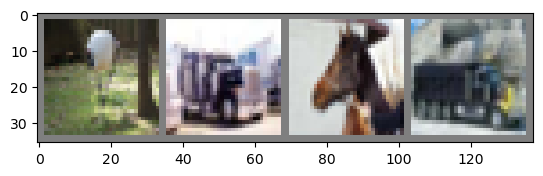

bird  truck horse truck


In [25]:
# Visualiza some of the images we downloaded
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5 # unnormalize the image
    npimg = img.numpy() # convert to numpy array
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # transpose the dimensions to (height, width, channels)
    plt.show()

# get some random training images
dataiter = iter(trainloader)   
data, items = next(dataiter) # get a batch of training data
imshow(torchvision.utils.make_grid(data)) # visualize the batch of images
print(' '.join(f'{classes[items[j]]:5s}' for j in range(batch_size))) # print the corresponding labels for the images

### Define Convolutional Neural Network
Same as last time but using 3-channels images instead of 1-channel images

In [26]:
class Net(nn.Module):
    def __init__(self):
        super().__init__() # call the parent class constructor
        # Convolution layer 1: 3 input channels (picture), 6 output channels (feature maps), kernel size of 5 (5x5 search window)
        self.conv1 = nn.Conv2d(3, 6, 5)

        # a pooling/subsampling layer will be used after c1
        self.pool = nn.MaxPool2d(2, 2)

        # Convolution Layer 3: 6 input channels (feature maps from conv1), 16 output channels (feature maps), kernel size of 5 (5x5 search window)
        self.conv2 = nn.Conv2d(6, 16, 5)

        # this subsampled layer will be flattened and fed into 3 fully connected layers, which will output the final classification results.
        # Fully Connected Layer 1: 16*5*5 input features (flattened feature maps from conv2), 120 output features (neurons)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # Fully Connected Layer 2: 120 input features (neurons from fc1), 84 output features (neurons)
        self.fc2 = nn.Linear(120, 84)
        # Fully Connected Layer 3: 84 input features (neurons from fc2), 10 output features (neurons, corresponding to the number of classes in the classification task)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Layer C1 followed by pooling into Layer S2

        x = self.pool(F.relu(self.conv2(x))) # Layer C3 followed by pooling into Layer S4

        x = torch.flatten(x, 1) # Flatten the output from the subsampling layer S4 in all dimensions except the batch dimension

        x = F.relu(self.fc1(x)) # Fully Connected Layer F5 with ReLU activation function

        x = F.relu(self.fc2(x)) # Fully Connected Layer F6 with ReLU activation function

        x = self.fc3(x) # Fully Connected Layer F7 (output layer) without activation function
        return x

In [27]:
net = Net()
print(net)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


### Loss Function and optimizer
Define with `torch.optim`

[Learning Rate]("https://developers.google.com/machine-learning/crash-course/linear-regression/hyperparameters#learning_rate") - defines how quickly the model converges and stabilizes. A low learning rate converges very slowly (after too many iterations), a high learning rate may bounce around and never converge or may curve up drastically after a few iterations. It is imperative to find a proper learning rate that will allow the model to converge properly.

[Momentum]() - The loss function can sometimes oscillate between different local minima or just get stuck. **Momentum** helps smooth oscillations and allows for the gradient to move toward the absolute minimum. It adds a fraction of the previous updated loss to the new loss.

$$v_t = {\beta}v_{t-1} + (1 - \beta){\nabla}L(\theta)$$
$$\theta = \theta - v_t$$
Where:
- $v_t$ = velocity (direction and speed of gradient)
- $\beta$ = momentum coefficient (usually between 0.5 and 0.9)
- ${\nabla}L(\theta)$ - gradient of the loss with respect to parameters $\theta$
- $\theta$ - model parameters (weights, biases)

In [28]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss() # Cross-entropy loss function for classification tasks
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # SGD optimizer with learning rate of 0.001 and momentum of 0.9

### Train the network
We loop over the data iterator and feed inputs to the network and optimize.

In [29]:
for epoch in range(2): # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0
print('Finished Training')

[1,  2000] loss: 2.203
[1,  4000] loss: 1.827
[1,  6000] loss: 1.637
[1,  8000] loss: 1.553
[1, 10000] loss: 1.502
[1, 12000] loss: 1.470
[2,  2000] loss: 1.398
[2,  4000] loss: 1.374
[2,  6000] loss: 1.346
[2,  8000] loss: 1.307
[2, 10000] loss: 1.304
[2, 12000] loss: 1.284
Finished Training


In [30]:
# Save the trained model's state dictionary (parameters) to a file named 'cifar_net.pth'
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

### Test the Network

We need to check if the network has learned anything at all by predicting the class label and comparing it with the ground truth. For now, we will just calculate accuracy with this.

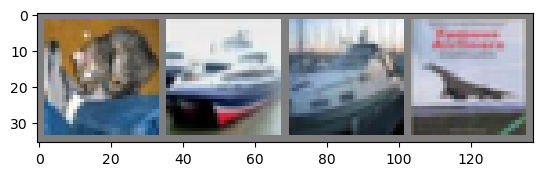

GroundTruth:  cat   ship  ship  plane


In [31]:
# Step 1: display an image from the test set
dataiter = iter(testloader) # create an iterator for the test data
images, labels = next(dataiter) # get a batch of test images and their corresponding labels
imshow(torchvision.utils.make_grid(images)) # visualize the batch of test images
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size))) # print the corresponding labels for the test images

In [32]:
# load in the model's state dictionary (parameters) from the file 'cifar_net.pth'
net = Net() # create a new instance of the network
net.load_state_dict(torch.load(PATH, weights_only=True)) # load the saved state dictionary into the network

<All keys matched successfully>

In [33]:
output = net(images) # forward pass the test images through the network

In [34]:
# energies for the 10 classes. the higher the energy for a class, the more likely the network thinks the input image belongs to that class.
_, predicted = torch.max(output, 1) # get the index of the class with the highest energy for each image in the batch
print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   ship  ship  ship 


In [35]:
# lets see how the network performs on the whole test set
correct = 0
total = 0
with torch.no_grad(): # since we aren't training, we don't need to calculate gradients for our outputs
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1) # get the index of the class with the highest energy for each image in the batch
        total += labels.size(0) # increment total by the number of labels in the batch
        correct += (predicted == labels).sum().item() # increment correct by the number of correct predictions in the batch

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total} %')

Accuracy of the network on the 10000 test images: 53.75 %


In [36]:
# do the same for each class to find which class performed the best
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 52.5 %
Accuracy for class: car   is 70.7 %
Accuracy for class: bird  is 21.6 %
Accuracy for class: cat   is 33.5 %
Accuracy for class: deer  is 58.6 %
Accuracy for class: dog   is 36.4 %
Accuracy for class: frog  is 48.9 %
Accuracy for class: horse is 75.9 %
Accuracy for class: ship  is 73.1 %
Accuracy for class: truck is 66.3 %
